In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

In [6]:
df = pd.read_csv("best_data.csv")

In [12]:
df.drop("Unnamed: 0", axis= 1, inplace=True)

# PCA

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [15]:
X = df.drop("Average_Bleaching", axis=1)
Y = df["Average_Bleaching"]

In [16]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [17]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [18]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [19]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

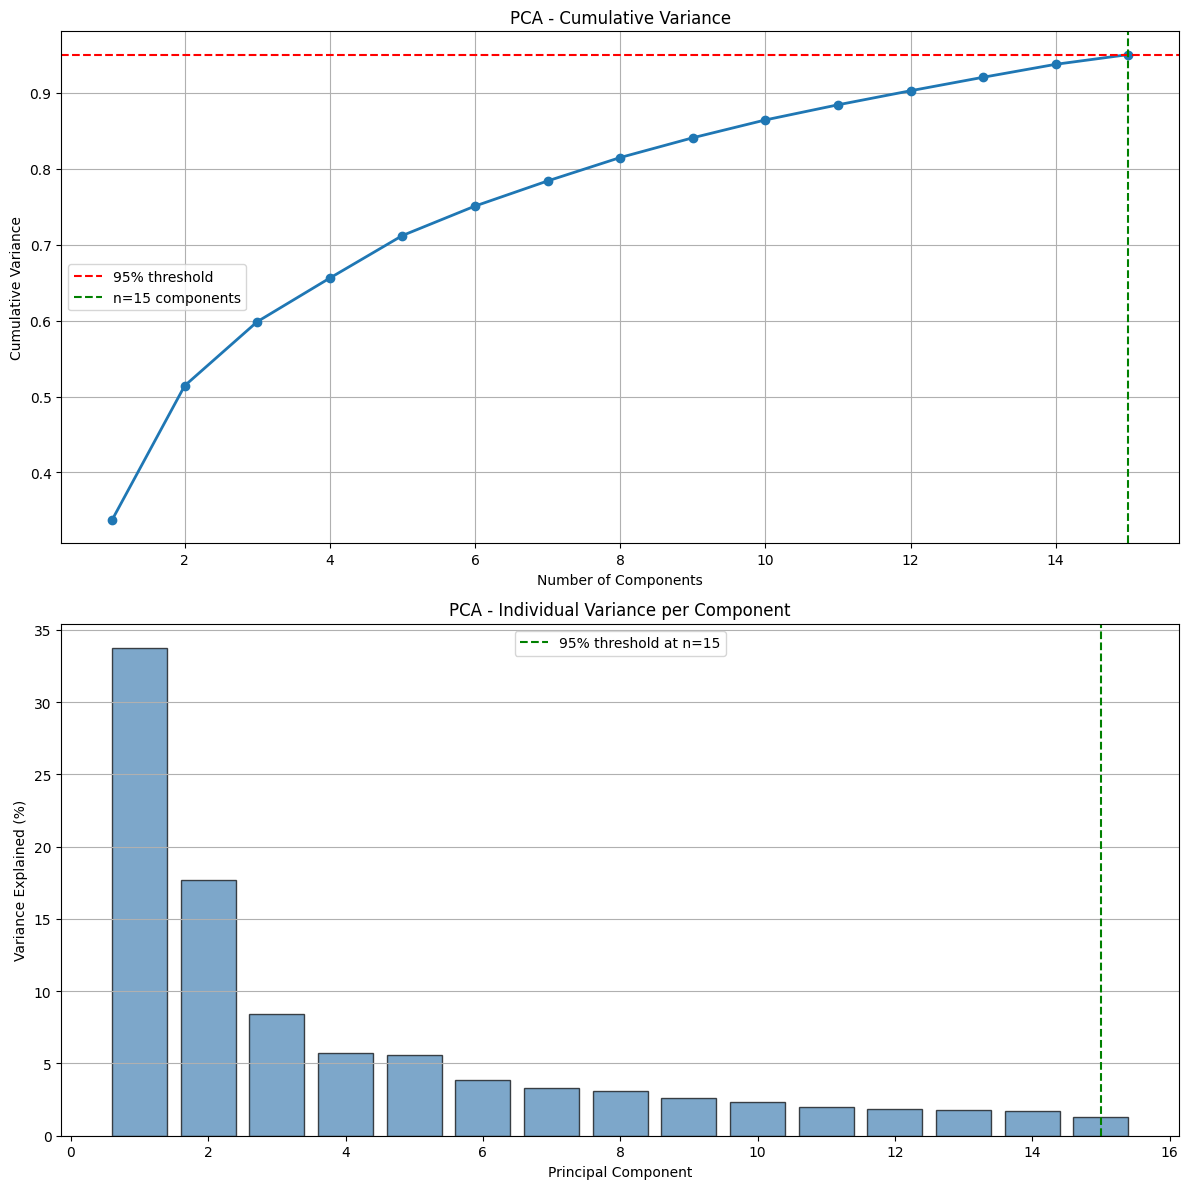

✅ Components needed for 95% variance: 15
✅ Variance explained by 15 components: 0.9505


In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax1.axvline(x=n_components_95, color='g', linestyle='--', 
            label=f'n={n_components_95} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'95% threshold at n={n_components_95}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 95% variance: {n_components_95}")
print(f"✅ Variance explained by {n_components_95} components: {cumvar[n_components_95-1]:.4f}")

In [21]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month], axis=1)
X_test_pca = pd.concat([X_test_pca_df, X_test_raw_month], axis=1)

# lazyPredict

In [23]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [24]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

                               Adjusted R-Squared      R-Squared         RMSE  \
Model                                                                           
ExtraTreesRegressor                      0.408059       0.421137     7.369610   
HistGradientBoostingRegressor            0.405150       0.418293     7.387697   
RandomForestRegressor                    0.354103       0.368374     7.698159   
MLPRegressor                             0.339251       0.353850     7.786162   
BaggingRegressor                         0.316540       0.331641     7.918844   
KNeighborsRegressor                      0.314379       0.329528     7.931350   
XGBRegressor                             0.295008       0.310585     8.042613   
GradientBoostingRegressor                0.274879       0.290901     8.156623   
PoissonRegressor                         0.182081       0.200153     8.662842   
Lars                                     0.095207       0.115198     9.111288   
TransformedTargetRegressor  

# OpTuna

In [26]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor

In [26]:
# ── prepare a version of X_train that already has month columns ──
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_train_no_month = X_train_raw.copy()   # numeric only (month already dropped earlier)
X_train_month    = X_train_raw_month.reset_index(drop=True)

# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_month(pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold

    # Reset all indices upfront so iloc slicing stays aligned
    X_num = X_num.reset_index(drop=True)
    X_mon = X_mon.reset_index(drop=True)
    y     = y.reset_index(drop=True)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        # fit the pipeline (impute+scale+pca) on numeric only
        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))   # R²
    return np.mean(scores)

In [ ]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int("n_estimators", 50, 300),
        max_depth        = trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

In [ ]:
def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 50, 300),
        max_depth         = trial.suggest_int("max_depth", 5, 40),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=50)
print("========== RF BEST ==========")
print(rf_study.best_params)
print(f"Best R²: {rf_study.best_value:.4f}")

In [ ]:
def hgb_objective(trial):
    model = HistGradientBoostingRegressor(
        max_iter          = trial.suggest_int  ("max_iter",          50, 400),
        max_depth         = trial.suggest_int  ("max_depth",          3,  15),
        learning_rate     = trial.suggest_float("learning_rate",  0.005, 0.1),
        min_samples_leaf  = trial.suggest_int  ("min_samples_leaf",   1,  50),
        l2_regularization = trial.suggest_float("l2_regularization", 0.0, 1.0),
        random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

hgb_study = optuna.create_study(direction="maximize")
hgb_study.optimize(hgb_objective, n_trials=50)
print("========== HGB BEST ==========")
print(hgb_study.best_params)
print(f"Best R²: {hgb_study.best_value:.4f}")

# Start

In [45]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=164,
    max_depth=10,
    learning_rate=0.08,
    min_samples_leaf=28,
    l2_regularization=0.754,
    random_state=42
)
# {'max_iter': 164, 'max_depth': 10, 'learning_rate': 0.08022417608998425, 'min_samples_leaf': 28, 'l2_regularization': 0.7544544718666345}


et_model = ExtraTreesRegressor(
    n_estimators=111,
    max_depth=32,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
# ========== ET BEST ==========
# {'n_estimators': 111, 'max_depth': 32, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


rf_model = RandomForestRegressor(
    n_estimators=190, 
    max_depth=32, 
    min_samples_split =  3,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1, 
    random_state=42
)
# {'n_estimators': 190, 'max_depth': 32, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

mlp_model = MLPRegressor(
    hidden_layer_sizes=(1,),
    activation='identity',              
    learning_rate_init=0.001,     
    max_iter=2000,          
    early_stopping=True,    
    n_iter_no_change=100,    
    random_state=42
)


In [46]:
stacking = StackingRegressor(
    estimators=[
        ('hgb', hgb_model),
        ('et',  et_model),
        ('rf',  rf_model)
    ],
    final_estimator=mlp_model,
    cv=4
)

stacking.fit(X_train_pca, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('hgb', ...), ('et', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",MLPRegressor(...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",4
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.08
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",164
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31


In [47]:
preds = stacking.predict(X_test_pca)
r2   = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"\n--- Single Split Results ---")
print(f"R-squared : {r2:.4f}")
print(f"RMSE      : {rmse:.4f}")


--- Single Split Results ---
R-squared : 0.4616
RMSE      : 7.1076


In [48]:
# หลังจาก stacking.fit() เสร็จ
final_estimator = stacking.final_estimator_   # MLP ที่ train แล้ว

# Weights และ biases ของแต่ละ layer
print("Layer weights (coefs_):")
for i, w in enumerate(final_estimator.coefs_):
    print(f"  Layer {i}: shape {w.shape}")
    print(w)
    print()

print("Layer biases (intercepts_):")
for i, b in enumerate(final_estimator.intercepts_):
    print(f"  Layer {i}: shape {b.shape}")
    print(b)
    print()

Layer weights (coefs_):
  Layer 0: shape (3, 1)
[[-0.4764616 ]
 [-0.89594892]
 [-0.03625901]]

  Layer 1: shape (1, 1)
[[-0.86093185]]

Layer biases (intercepts_):
  Layer 0: shape (1,)
[-0.08518317]

  Layer 1: shape (1,)
[-0.84423833]



Total iterations: 623
Initial loss: 152.5831
Final loss:   29.4593
Best validation R²: 0.1002


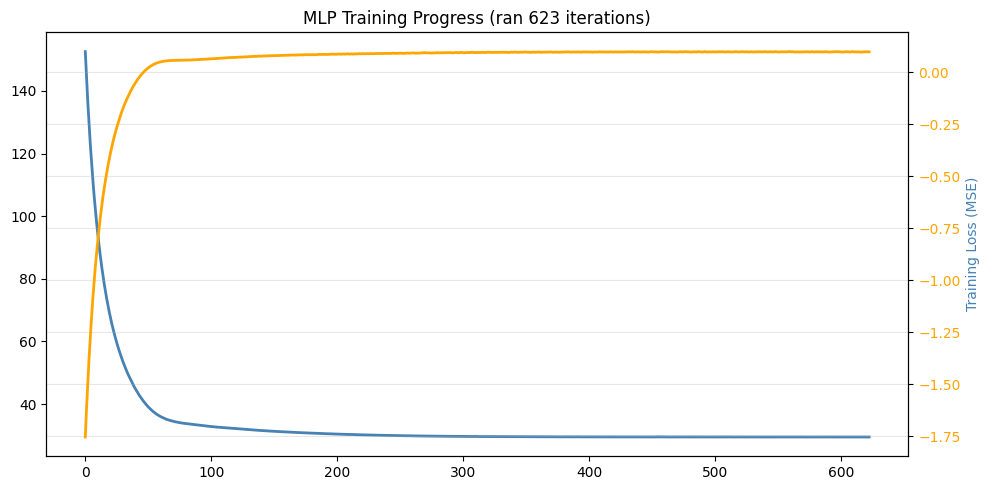


Converged: Early stopped
Iterations: 623 / 2000


In [49]:
import matplotlib.pyplot as plt

mlp = stacking.final_estimator_

# Loss info
print(f"Total iterations: {len(mlp.loss_curve_)}")
print(f"Initial loss: {mlp.loss_curve_[0]:.4f}")
print(f"Final loss:   {mlp.loss_curve_[-1]:.4f}")

# Best loss/score (depends on early_stopping)
if mlp.best_loss_ is not None:
    print(f"Best loss:    {mlp.best_loss_:.4f}")
elif hasattr(mlp, 'best_validation_score_'):
    print(f"Best validation R²: {mlp.best_validation_score_:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, label='Training Loss', linewidth=2, color='steelblue')

# Validation curve (if early_stopping enabled)
if hasattr(mlp, 'validation_scores_') and len(mlp.validation_scores_) > 0:
    ax2 = plt.gca().twinx()
    ax2.plot(mlp.validation_scores_, label='Validation R²', linewidth=2, color='orange')
    ax2.set_ylabel('Validation R²', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

plt.xlabel('Iteration')
plt.ylabel('Training Loss (MSE)', color='steelblue')
plt.title(f'MLP Training Progress (ran {mlp.n_iter_} iterations)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Convergence info
print(f"\nConverged: {'Early stopped' if mlp.n_iter_ < mlp.max_iter else 'Hit max_iter'}")
print(f"Iterations: {mlp.n_iter_} / {mlp.max_iter}")

In [42]:
# Predict ดูว่าค่าออกมาเหมาะสมไหม
y_pred = stacking.predict(X_test_pca)
print(f"Predictions range: {y_pred.min():.2f} to {y_pred.max():.2f}")
print(f"Mean prediction: {y_pred.mean():.2f}")
print(f"Actual range: {y_test.min():.2f} to {y_test.max():.2f}")
print(f"Mean actual: {y_test.mean():.2f}")

# R² และ RMSE ของ stacking
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Predictions range: -2.24 to 87.16
Mean prediction: 3.04
Actual range: 0.00 to 96.50
Mean actual: 2.89
R²: 0.4646
RMSE: 7.0875


# K-Fold

In [32]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_val_score

In [34]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Separate month columns before the loop
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_month    = X[month_cols].copy()
X_no_month = X.drop(columns=month_cols)

r2_scores, rmse_scores, mae_scores = [], [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_no_month), 1):
    # Split numeric and month separately
    X_fold_train, X_fold_test = X_no_month.iloc[train_idx], X_no_month.iloc[test_idx]
    month_fold_train = X_month.iloc[train_idx].reset_index(drop=True)
    month_fold_test  = X_month.iloc[test_idx].reset_index(drop=True)
    y_fold_train     = Y.iloc[train_idx].reset_index(drop=True)
    y_fold_test      = Y.iloc[test_idx].reset_index(drop=True)

    # Impute → Scale → PCA (numeric only)
    imputer     = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_fold_train)
    X_test_imp  = imputer.transform(X_fold_test)

    scaler      = StandardScaler()
    X_train_ss  = scaler.fit_transform(X_train_imp)
    X_test_ss   = scaler.transform(X_test_imp)

    pca         = PCA(n_components=0.95)
    X_train_pca_fold = pca.fit_transform(X_train_ss)
    X_test_pca_fold  = pca.transform(X_test_ss)

    # Reattach month columns after PCA
    n_pcs   = X_train_pca_fold.shape[1]
    pc_cols = [f'PC{i+1}' for i in range(n_pcs)]
    X_train_final = pd.concat([pd.DataFrame(X_train_pca_fold, columns=pc_cols), month_fold_train], axis=1)
    X_test_final  = pd.concat([pd.DataFrame(X_test_pca_fold,  columns=pc_cols), month_fold_test ], axis=1)

    # Stacking — สร้างใหม่ทุก fold
    stacking = StackingRegressor(
        estimators=[
            ('hgb', hgb_model),
            ('et',  et_model),
            ('rf',  rf_model)
        ],
        final_estimator=mlp_model,
        cv=4
    )
    stacking.fit(X_train_final, y_fold_train)

    preds = stacking.predict(X_test_final)
    r2_scores.append(r2_score(y_fold_test, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))
    mae_scores.append(mean_absolute_error(y_fold_test, preds))

    print(f"Fold {fold}  →  R²: {r2_scores[-1]:.4f}  |  RMSE: {rmse_scores[-1]:.4f}  |  MAE: {mae_scores[-1]:.4f}")

print(f"\n--- {n_splits}-Fold Stacking (MLP meta) Summary ---")
print(f"R²   mean: {np.mean(r2_scores):.4f}  ±  {np.std(r2_scores):.4f}")
print(f"RMSE mean: {np.mean(rmse_scores):.4f}  ±  {np.std(rmse_scores):.4f}")
print(f"MAE  mean: {np.mean(mae_scores):.4f}  ±  {np.std(mae_scores):.4f}")

Fold 1  →  R²: 0.3501  |  RMSE: 7.5560  |  MAE: 3.2477
Fold 2  →  R²: 0.1868  |  RMSE: 9.8070  |  MAE: 3.5823
Fold 3  →  R²: 0.1338  |  RMSE: 9.0633  |  MAE: 3.3867
Fold 4  →  R²: 0.2177  |  RMSE: 7.3905  |  MAE: 2.9137

--- 4-Fold Stacking (MLP meta) Summary ---
R²   mean: 0.2221  ±  0.0798
RMSE mean: 8.4542  ±  1.0173
MAE  mean: 3.2826  ±  0.2439
